# Aerial and latitude–height animations (Eriswil)

Notebook aligned with the publication pipeline: `scripts/processing_chain/run_publication_figures.py` reads
`config/publication_figures.yaml` (ensemble, paths, per-job CLI defaults). Process-budget and time-zero context live in
`config/psd_process_evolution.yaml`.

**Outputs:** frames under `output/gfx/png/aerials/<cs_run>/`, MP4/GIF under `output/gfx/mp4/` (same tree as other promoted figures; `run_publication_figures.py` syncs `output/gfx` → `output/gallery`).

**Data:** the notebook resolves `.../ensemble_output/<cs_run>` using the same fallbacks as `get_output_root` in `processing_paths.py`: `paths.server_root` in YAML, then `CS_RUNS_DIR`, `POLARCAP_OUTPUT_ROOT`, the Levante default tree, then local `scripts/data/registry/processed`. Jupyter kernels often lack shell exports—set `CS_RUNS_DIR` in IPython startup or assign `os.environ["CS_RUNS_DIR"] = "..."` before the config cell.

**Combine top + side MP4 (server ffmpeg):**

```bash
"/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-wuuo72/bin/ffmpeg" -y \
  -i output/gfx/mp4/lat_lon_multi_flare_100m_cs-eriswil_20260318_153631.mp4 \
  -i output/gfx/mp4/lat_height_multi_flare_100m_cs-eriswil_20260318_153631.mp4 \
  -filter_complex "[0:v]fps=15,scale=960:540[top];[1:v]fps=15,scale=960:540[side];[top][side]vstack=inputs=2[stack];[stack]scale=1920:1080:flags=lanczos,setsar=1[v]" \
  -map "[v]" -r 15 -c:v libx264 -crf 18 -preset slow -pix_fmt yuv420p -movflags +faststart -shortest \
  output/gfx/mp4/lat_top_side_combined_multi_flare_100m_cs-eriswil_20260318_153631_1920x1080.mp4
```

In [1]:
FLARE_IDX_LIST=(0, 1, 2, 3, 4)
REF_IDX_LIST=(0, 1, 1, 1, 1)

In [2]:
import glob
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as md
import numpy as np
import pandas as pd
import xarray as xr
import yaml
from matplotlib.colors import LogNorm
from dask.diagnostics import ProgressBar
from utilities.ensemble_config_diff import print_ensemble_config_diff



def find_repo_root(start: Path | None = None) -> Path:
    """Match notebooks/spectral_waterfall_minimal: stable root from any cwd."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "utilities" / "spectral_waterfall.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook inside the polarcap_analysis repository.")


REPO_ROOT = find_repo_root()
SRC_DIR = REPO_ROOT / "src"
for path in (REPO_ROOT, SRC_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from utilities.model_helpers import fetch_3d_data, convert_units_3d, harmonize_experiment_time_to_finest
from utilities.namelist_metadata import update_dataset_metadata
from utilities.plotting import new_fjet2, set_name_tick_params, add_ruler
from utilities.processing_paths import find_ensemble_output_for_cs_run
from utilities.style_profiles import apply_publication_style, proc_color
import utilities.tools as tools

xr.set_options(keep_attrs=True)
apply_publication_style()

PUBLICATION_YAML = REPO_ROOT / "config" / "publication_figures100m.yaml"
PSD_YAML = REPO_ROOT / "config" / "psd_process_evolution100m.yaml"

TIME_DEBUG_STRIDE = 4

def _job_tokens(pub: dict, job_key: str) -> list[str]:
    out: list[str] = []
    for x in (pub.get("default_args") or {}).get(job_key, []) or []:
        out.extend(str(x).split())
    return out


def _flag_value(tokens: list[str], name: str) -> str | None:
    try:
        i = tokens.index(name)
    except ValueError:
        return None
    return tokens[i + 1] if i + 1 < len(tokens) else None


In [3]:
# Load publication + PSD configs (same files as the publication runner / cloud overview script)
with open(PUBLICATION_YAML) as f:
    pub = yaml.safe_load(f) or {}
with open(PSD_YAML) as f:
    psd = yaml.safe_load(f) or {}

ens = pub.get("ensemble") or {}
paths_cfg = pub.get("paths") or {}
cs_run = str(ens.get("cs_run", "cs-eriswil__20260318_153631"))
domain_xy = str(ens.get("domain", "200x160"))
flare_idx = int((psd.get("selection") or {}).get("experiment_index_default", 1))

server_root = os.environ.get("CS_RUNS_DIR")
ens_out, _tried = find_ensemble_output_for_cs_run(cs_run, config_runs_root=server_root)
if not ens_out:
    raise FileNotFoundError(
        "Could not find ensemble_output/"
        + cs_run
        + ". Tried:\n  "
        + "\n  ".join(_tried)
        + "\nSet paths.server_root in publication_figures.yaml, or export CS_RUNS_DIR "
        "(parent of RUN_ERISWILL_*x100), or POLARCAP_OUTPUT_ROOT (runs root or ensemble_output). "
        "Jupyter often does not inherit shell env: set variables in ~/.ipython/profile_default/startup "
        "or in this cell via os.environ before re-run."
    )
model_data_path = Path(ens_out) / cs_run

cf_tok = _job_tokens(pub, "cloud_field_overview")
extpar_high = server_root / Path('extPar_Eriswil_200x160.nc')
extpar_low = server_root / Path('extPar_Eriswil_50x40.nc')
plot_start_s = _flag_value(cf_tok, "--plot-start")
plot_end_s = _flag_value(cf_tok, "--plot-end")
if domain_xy == "200x160" and extpar_high:
    extpar_file = Path(extpar_high).expanduser()
elif extpar_low:
    extpar_file = server_root / extpar_low
else:
    extpar_file = Path(extpar_high or extpar_low or "").expanduser()

seed_start = np.datetime64((psd.get("time") or {}).get("seed_start", "2023-01-25T12:29:50"))

GFX_PNG = REPO_ROOT / "output" / "gfx" / "png" / "aerials" / cs_run.replace("/", "_")
GFX_MP4 = REPO_ROOT / "output" / "gfx" / "mp4"
GFX_PNG.mkdir(parents=True, exist_ok=True)
GFX_MP4.mkdir(parents=True, exist_ok=True)

print("cs_run:", cs_run, "domain:", domain_xy)
print("flare_idx:", flare_idx)
print("experiment:", model_data_path.name)

print("model_data_path:", model_data_path)
print("extpar_file:", extpar_file)
print("plot window (cloud_field_overview preset):", plot_start_s, "..", plot_end_s)


cs_run: cs-eriswil__20260318_153631 domain: 200x160
flare_idx: 3
experiment: cs-eriswil__20260318_153631
model_data_path: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_200x160x100/ensemble_output/cs-eriswil__20260318_153631
extpar_file: /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/extPar_Eriswil_200x160.nc
plot window (cloud_field_overview preset): 2026-03-23T12:25:00 .. 2026-03-23T13:00:00


In [4]:
server_root

'/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/'

## Load 3D flare member

In [16]:
flist_3d = sorted(glob.glob(str(model_data_path / "3D_??????????????.nc")))
if not flist_3d:
    raise FileNotFoundError(f"No 3D_*.nc under {model_data_path}")

json_files = sorted(model_data_path.glob("*.json"))
if not json_files:
    raise FileNotFoundError(f"No ensemble json next to 3D files in {model_data_path}")
with open(json_files[0]) as jsonfile:
    meta = json.load(jsonfile)

exp_names = [Path(f).name.split("_")[-1].split(".")[0] for f in flist_3d]
flare_candidates = [exp for exp in exp_names if meta[exp]["INPUT_ORG"]["sbm_par"]["lflare"]]
ref_candidates = [exp for exp in exp_names if not meta[exp]["INPUT_ORG"]["sbm_par"]["lflare"]]
if not flare_candidates:
    raise ValueError("No flare experiments (lflare) in ensemble meta.")
if not ref_candidates:
    raise ValueError("No reference experiments (lflare=False) in ensemble meta.")

# Load flare + reference runs once; keep expname as coordinate.
load_candidates = flare_candidates + [e for e in ref_candidates if e not in flare_candidates]
_ds_blocks = []
_dtimes = []
for exp_name in load_candidates:
    nc_file = next(f for f in flist_3d if exp_name in f)
    ds_i = fetch_3d_data(
        str(nc_file),
        str(extpar_file),
        meta[exp_name]["INPUT_ORG"],
        var_sets=["meteo", "bulk", "spec"],
        chunks={"time": 1},
    )
    ds_i = update_dataset_metadata(ds_i)
    ds_i = ds_i.isel(altitude=slice(80, None))
    ds_i = convert_units_3d(ds_i, ds_i["rho"])
    _dtimes.append(ds_i.time.values[1] - ds_i.time.values[0])
    _ds_blocks.append(ds_i)

_times = _ds_blocks[np.argmax(_dtimes)].time

print(
    "OUTPUT cadence (sbm_par.nc_output_hcomb last entry = dt, seconds):",
    {e: meta[e]["INPUT_ORG"]["sbm_par"].get("nc_output_hcomb") for e in load_candidates},
)
# Keep native cadence in ds_3d to avoid expensive interpolation on full 3D fields.
# We harmonize to 10 s later on reduced animation fields only.
ds_3d = xr.concat(_ds_blocks, dim=pd.Index(load_candidates, name="expname"))

# Development/debug speed-up: use every 4th model time step.
if TIME_DEBUG_STRIDE > 1:
    ds_3d = ds_3d.reindex(time=_times)
    # ds_3d = ds_3d.isel(time=slice(None, None, TIME_DEBUG_STRIDE))

flare_exp_name = flare_candidates[flare_idx]
print("flare_candidates:", flare_candidates)
print("ref_candidates:", ref_candidates)
print("loaded expname:", list(ds_3d.expname.values))
print("time_debug_stride:", TIME_DEBUG_STRIDE, "n_time:", ds_3d.sizes.get("time"))
print("default flare_exp_name (paths, tracking):", flare_exp_name)
print_ensemble_config_diff(meta, load_candidates)

OUTPUT cadence (sbm_par.nc_output_hcomb last entry = dt, seconds): {'20260318153634': [1730, 4000, 30], '20260318153638': [1730, 4000, 30], '20260324165035': [1730, 4000, 10], '20260324165038': [1730, 4000, 10], '20260324165040': [1730, 4000, 10], '20260318153631': [1730, 4000, 30], '20260318153636': [1730, 4000, 30]}


/tmp/ipykernel_865896/1820714711.py:46: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_3d = xr.concat(_ds_blocks, dim=pd.Index(load_candidates, name="expname"))


flare_candidates: ['20260318153634', '20260318153638', '20260324165035', '20260324165038', '20260324165040']
ref_candidates: ['20260318153631', '20260318153636']
loaded expname: ['20260318153634', '20260318153638', '20260324165035', '20260324165038', '20260324165040', '20260318153631', '20260318153636']
time_debug_stride: 4 n_time: 77
default flare_exp_name (paths, tracking): 20260324165038
Ensemble config differences (COSMO-SPECS / INPUT_ORG)
experiments (7): 20260318153634, 20260318153638, 20260324165035, 20260324165038, 20260324165040, 20260318153631, 20260318153636

INPUT_ORG.flare_sbm.flare_dn
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 400.0
  20260324165038: 400.0
  20260324165040: 400.0
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_dp
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1e-07
  20260324165038: 1e-07
  20260324165040: 1e-07
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_emission
  202603

In [17]:

print_ensemble_config_diff(meta, flare_candidates)


Ensemble config differences (COSMO-SPECS / INPUT_ORG)
experiments (5): 20260318153634, 20260318153638, 20260324165035, 20260324165038, 20260324165040

INPUT_ORG.flare_sbm.flare_dn
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 400.0
  20260324165038: 400.0
  20260324165040: 400.0

INPUT_ORG.flare_sbm.flare_dp
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1e-07
  20260324165038: 1e-07
  20260324165040: 1e-07

INPUT_ORG.flare_sbm.flare_emission
  20260318153634: 1000000.0
  20260318153638: 1000000.0
  20260324165035: 1000000.0
  20260324165038: 3000000.0
  20260324165040: 10000000.0

INPUT_ORG.flare_sbm.flare_sig
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1.75
  20260324165038: 1.75
  20260324165040: 1.75

INPUT_ORG.flare_sbm.lflare_ccn
  20260318153634: False
  20260318153638: False
  20260324165035: True
  20260324165038: True
  20260324165040: True

INPUT_ORG.sbm_par.ishape
  20260318153634: 2
  20260318153638: 4
  20260324165035: 4
  

In [18]:

print_ensemble_config_diff(meta, flare_candidates)


# # All experiments in the JSON
print_ensemble_config_diff( 
    meta,
    flare_candidates, 
    subtrees=("INPUT_ORG", "domain"),
)

# Also compare top-level domain string
# print_ensemble_config_diff(meta, flare_candidates, subtrees=("INPUT_ORG", "domain"))

Ensemble config differences (COSMO-SPECS / INPUT_ORG)
experiments (5): 20260318153634, 20260318153638, 20260324165035, 20260324165038, 20260324165040

INPUT_ORG.flare_sbm.flare_dn
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 400.0
  20260324165038: 400.0
  20260324165040: 400.0

INPUT_ORG.flare_sbm.flare_dp
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1e-07
  20260324165038: 1e-07
  20260324165040: 1e-07

INPUT_ORG.flare_sbm.flare_emission
  20260318153634: 1000000.0
  20260318153638: 1000000.0
  20260324165035: 1000000.0
  20260324165038: 3000000.0
  20260324165040: 10000000.0

INPUT_ORG.flare_sbm.flare_sig
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1.75
  20260324165038: 1.75
  20260324165040: 1.75

INPUT_ORG.flare_sbm.lflare_ccn
  20260318153634: False
  20260318153638: False
  20260324165035: True
  20260324165038: True
  20260324165040: True

INPUT_ORG.sbm_par.ishape
  20260318153634: 2
  20260318153638: 4
  20260324165035: 4
  

In [19]:
# Map-view layout: figure size from publication DPI (matches savefig in analysis scripts)
_dpi = float(plt.rcParams["savefig.dpi"])
pixel_w, pixel_h = 1920, 1080
resolution_label = "400m" if domain_xy == "50x40" else "100m"
resolution_deg = 0.004 if domain_xy == "50x40" else 0.001

cfg = {
    "resolution": resolution_label,
    "resolution_deg": resolution_deg,
    "dpi": int(_dpi),
    "pixel_size_latlon": (pixel_w, pixel_h),
    "pixel_size_latheight": (pixel_w, pixel_h//1.75),
    "poolsize": min(8, os.cpu_count() or 4),
    "plot_all_frames": True,
    # Lat–height panel: faint HSURF columns + thick mean, or one column synced to frame index. ("individual", "all_mean")
    "latheight_surf_mode": "all_mean", 
    "flare_lat": 47.07425,
    "flare_lon": 7.90522,
    "origin_lat": 47.070522,
    "origin_lon": 7.872991,
    "plot_xlim": (7.7671843, 7.94),
    "plot_ylim": (47.02, 47.12),
    "delta_x": float(1e3 * np.mean(np.diff(ds_3d.longitude.values)) * 111.13295254925466),
    "delta_y": float(1e3 * np.mean(np.diff(ds_3d.latitude.values)) * 111.13295254925466),
    "delta_t": float(np.mean(np.diff(ds_3d.time.astype("datetime64[s]")).astype(float))),
    "n_lon": ds_3d.longitude.size,
    "n_lat": ds_3d.latitude.size,
    "n_time": ds_3d.time.size,
    "vel_lims": [-0.5, 0.5],
    "v_lims_qi": [1e1, 1e4],
    "tick_size": int(plt.rcParams["xtick.labelsize"] + 1),
    "axis_size": int(plt.rcParams["axes.labelsize"] + 2),
    "timer_size": int(plt.rcParams["figure.titlesize"] + 6),
}

data_extpar = xr.open_mfdataset(str(extpar_file), chunks="auto")
lat2d = data_extpar["lat"].values[7:-7, 7:-7]
lon2d = data_extpar["lon"].values[7:-7, 7:-7]
height = data_extpar["HSURF"].values[7:-7, 7:-7]


In [20]:
ds_3d

<xarray.Dataset> Size: 834GB
Dimensions:      (diameter: 66, time: 77, longitude: 186, latitude: 146,
                  altitude: 20, expname: 7)
Coordinates:
  * diameter     (diameter) float64 528B 0.00226 0.002847 ... 7.523e+03
  * time         (time) datetime64[ns] 616B 2023-01-25T12:28:50 ... 2023-01-2...
  * longitude    (longitude) float32 744B 7.736 7.738 7.739 ... 8.007 8.008
  * latitude     (latitude) float32 584B 47.0 47.0 47.0 ... 47.14 47.14 47.14
  * altitude     (altitude) float64 160B 1.521e+03 1.458e+03 ... 836.9 827.6
  * expname      (expname) object 56B '20260318153634' ... '20260318153636'
    latitude2D   (latitude, longitude) float32 109kB 47.0 47.0 ... 47.14 47.14
    longitude2D  (latitude, longitude) float32 109kB 7.737 7.738 ... 8.007 8.008
    altitude3D   (altitude, latitude, longitude) float64 4MB 1.43e+03 ... 533.5
Data variables: (12/31)
    t            (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    p0           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    pp           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    qv           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    rho0         (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    rho          (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    ...           ...
    qwtot        (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    qftot        (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    nc           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    nr           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    ni           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
    ns           (expname, time, altitude, latitude, longitude) float64 2GB dask.array<chunksize=(1, 1, 20, 146, 186), meta=np.ndarray>
Attributes:
    ncfile:   /work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/R...
    run_id:   20260318153634

In [21]:
# Flare–reference pairs from FLARE_IDX_LIST / REF_IDX_LIST (indices into flare_candidates / ref_candidates).
eps_f32 = np.finfo(np.float32).eps

def _ishape_of(exp_name):
    return meta[exp_name]["INPUT_ORG"]["sbm_par"].get("ishape")

_fi = list(FLARE_IDX_LIST)
_ri = list(REF_IDX_LIST)
if len(_fi) != len(_ri):
    raise ValueError(
        f"FLARE_IDX_LIST length {len(_fi)} != REF_IDX_LIST length {len(_ri)}"
    )
pair_rows = []
for j, (i_f, i_r) in enumerate(zip(_fi, _ri)):
    if not (0 <= i_f < len(flare_candidates)):
        raise IndexError(
            f"FLARE_IDX_LIST[{j}]={i_f} invalid for len(flare_candidates)={len(flare_candidates)}"
        )
    if not (0 <= i_r < len(ref_candidates)):
        raise IndexError(
            f"REF_IDX_LIST[{j}]={i_r} invalid for len(ref_candidates)={len(ref_candidates)}"
        )
    fexp = flare_candidates[i_f]
    rexp = ref_candidates[i_r]
    pair_rows.append((fexp, rexp, _ishape_of(fexp)))

n_pair = len(pair_rows)
if n_pair < 1:
    raise ValueError("No pairs built from FLARE_IDX_LIST / REF_IDX_LIST.")
print("pair index tuples (flare_i, ref_i):", list(zip(_fi, _ri)))
print("pair_rows (flare, ref, ishape):", pair_rows)

_col = ds_3d[["nw", "nf", "dz"]].sel(
    latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
    longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
)
_col = _col.isel(diameter=slice(30, None)).sum("diameter")
_col = (_col[["nw", "nf"]] * _col["dz"]).sum("altitude")
with ProgressBar():
    _col = xr.where(_col < eps_f32, np.nan, _col)

itime_cmp = int(_col.sizes["time"] // 2)
_tlab = str(np.asarray(_col.time.isel(time=itime_cmp).values).squeeze())

_d0 = _col["nf"].isel(time=itime_cmp).sel(expname=pair_rows[0][0])
if "longitude2D" in _d0.coords:
    lon_q = _d0.longitude2D.values
    lat_q = _d0.latitude2D.values
else:
    lon_q, lat_q = np.meshgrid(_d0.longitude.values, _d0.latitude.values)


pair index tuples (flare_i, ref_i): [(0, 0), (1, 1), (2, 1), (3, 1), (4, 1)]
pair_rows (flare, ref, ishape): [('20260318153634', '20260318153631', 2), ('20260318153638', '20260318153636', 4), ('20260324165035', '20260318153636', 4), ('20260324165038', '20260318153636', 4), ('20260324165040', '20260318153636', 4)]


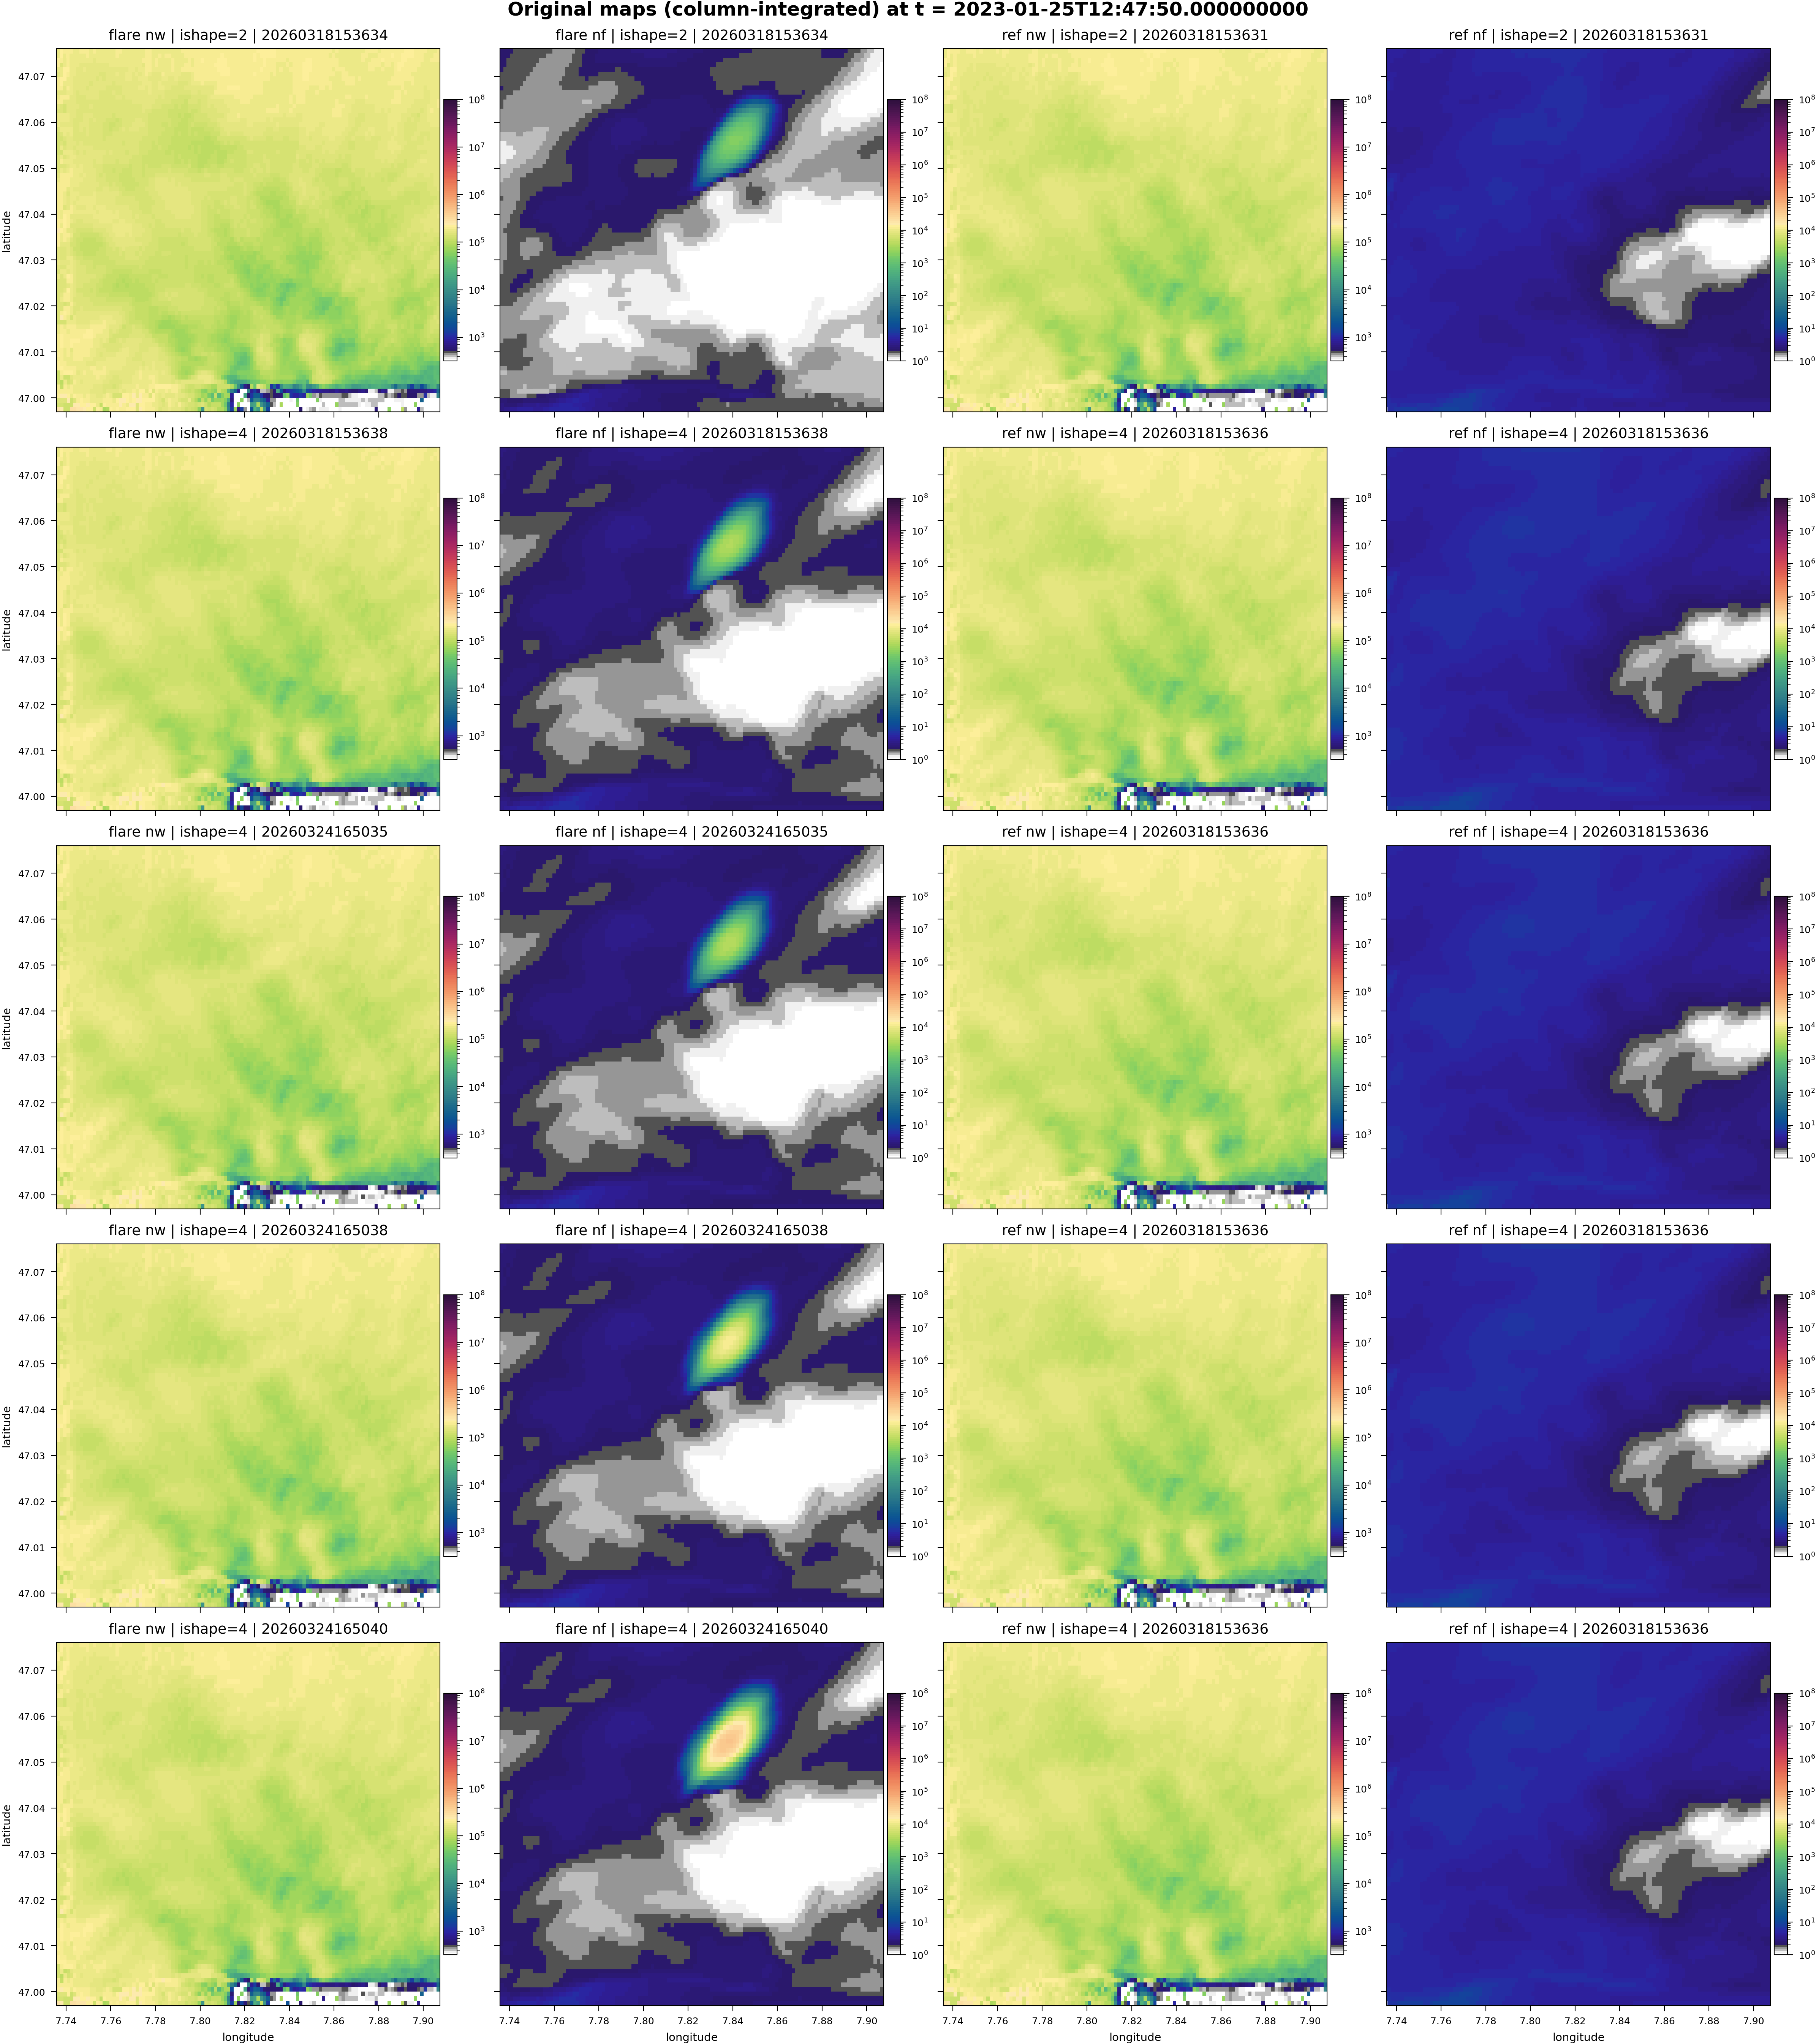

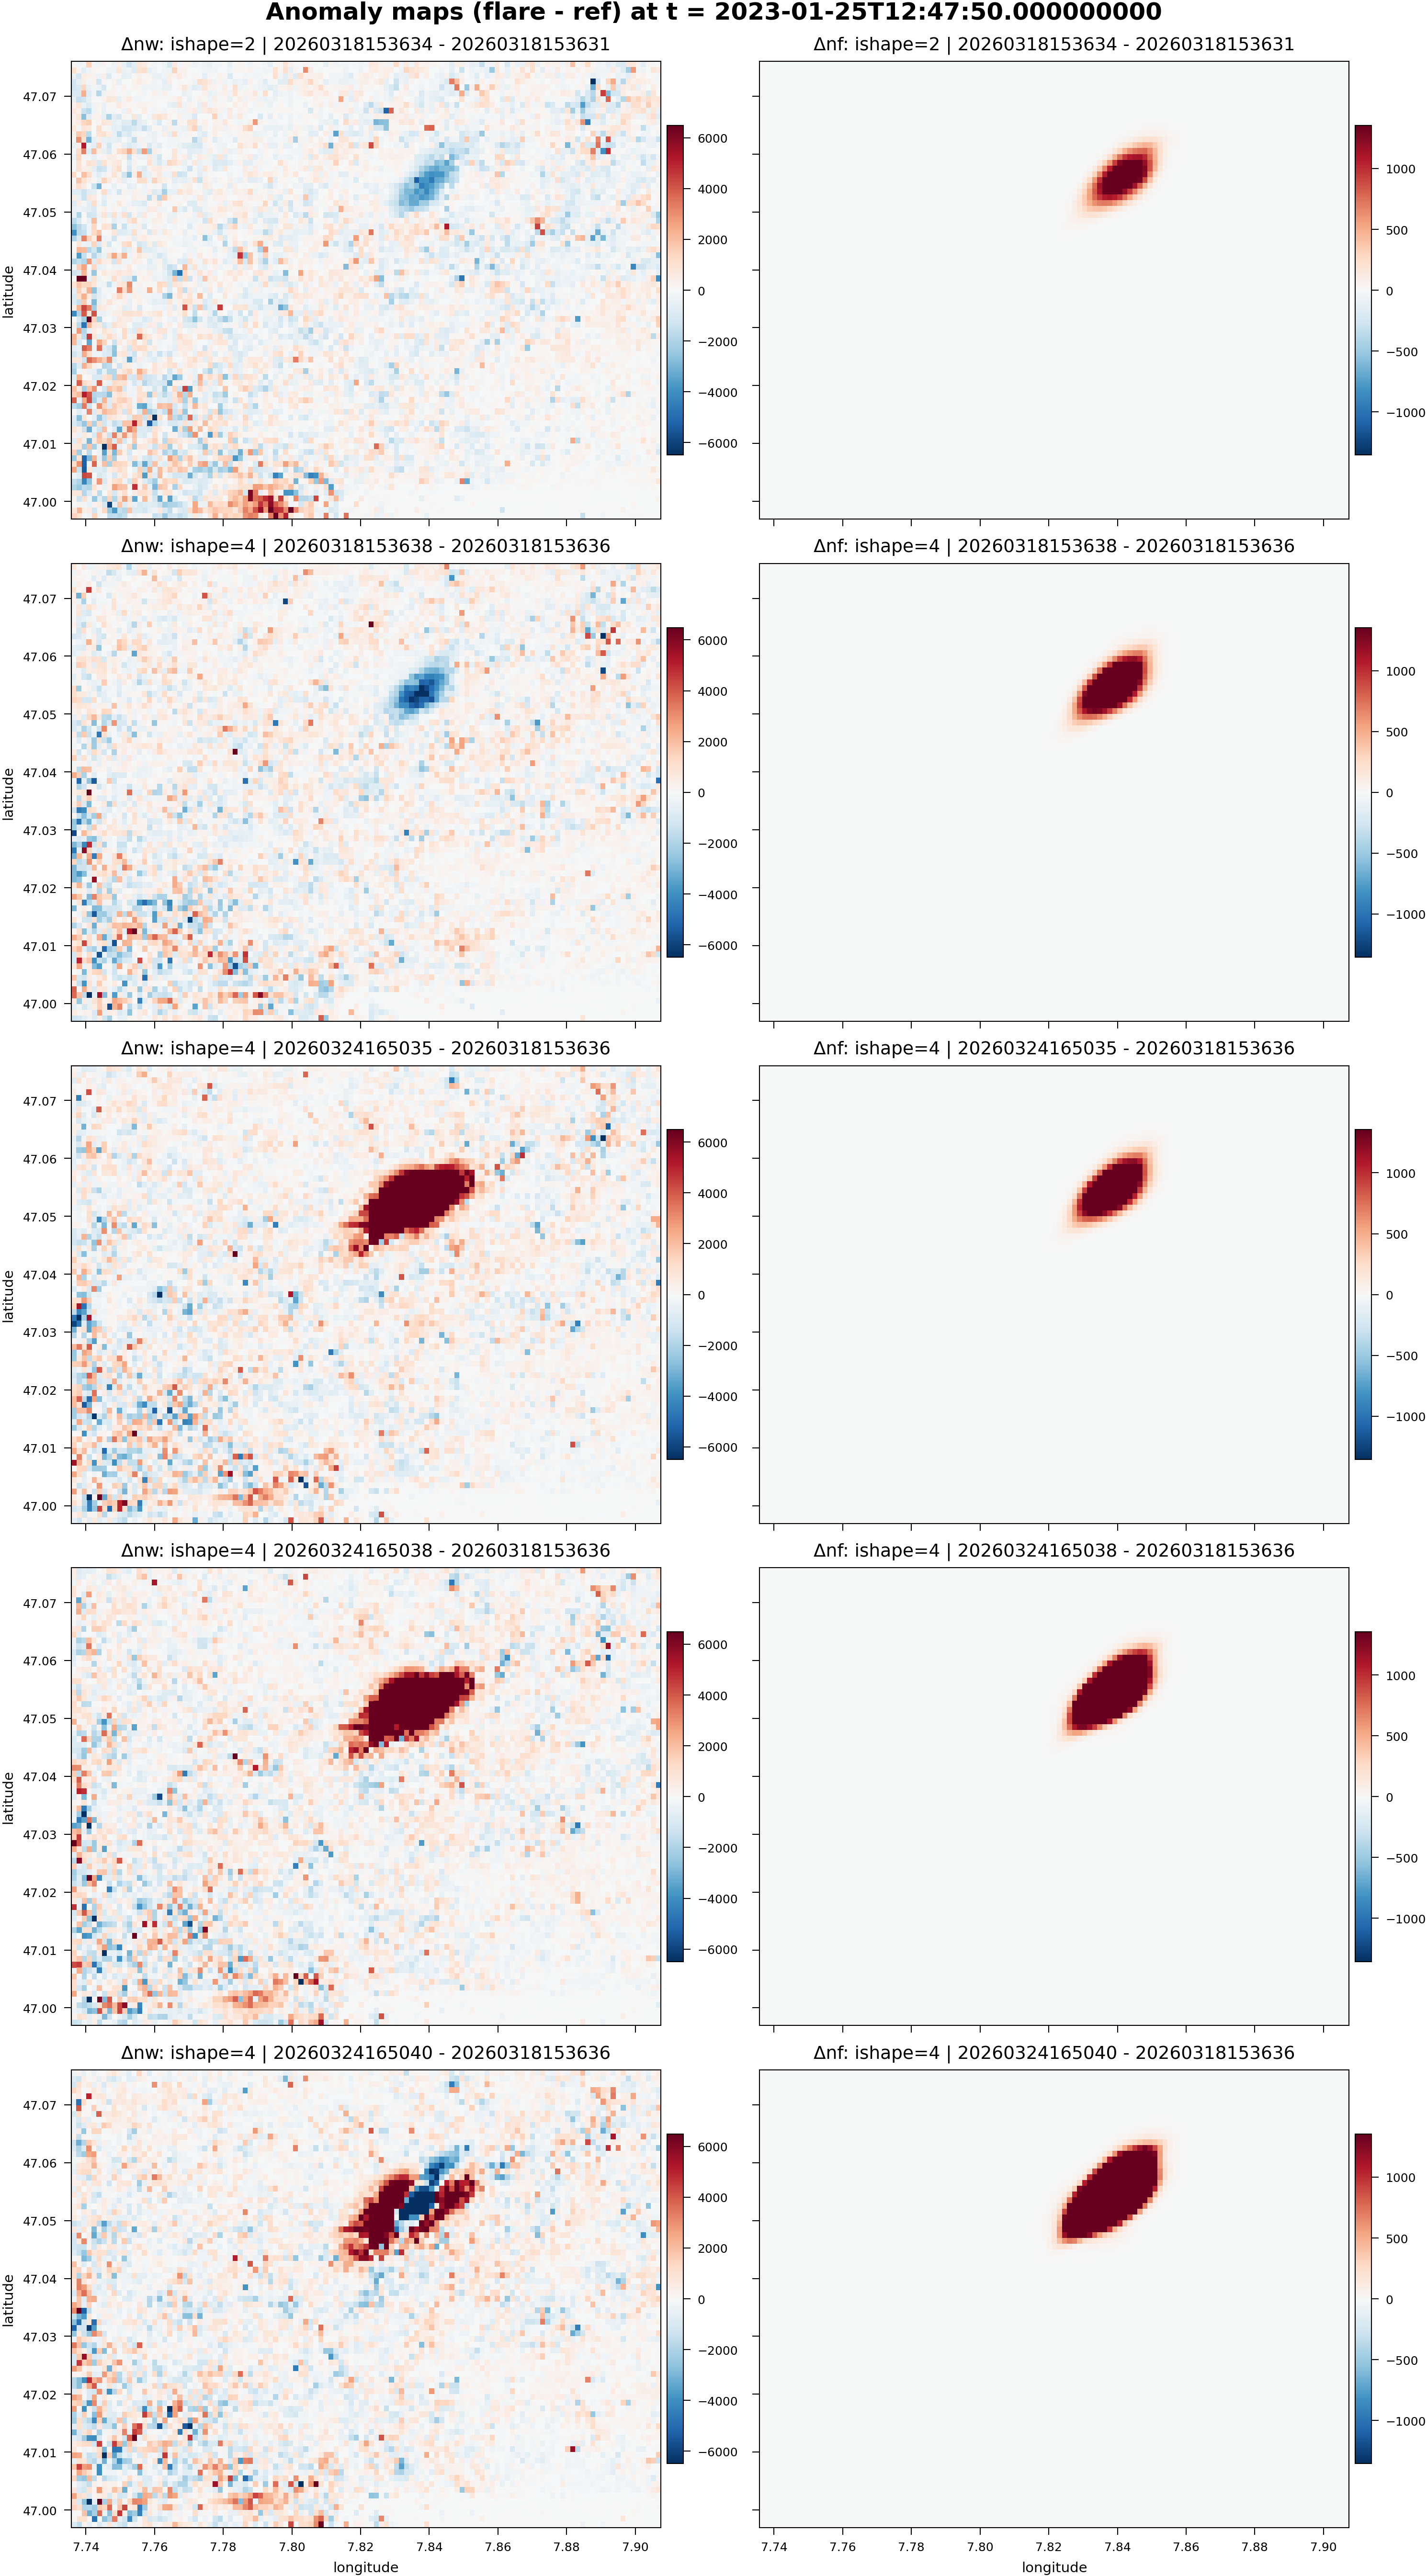

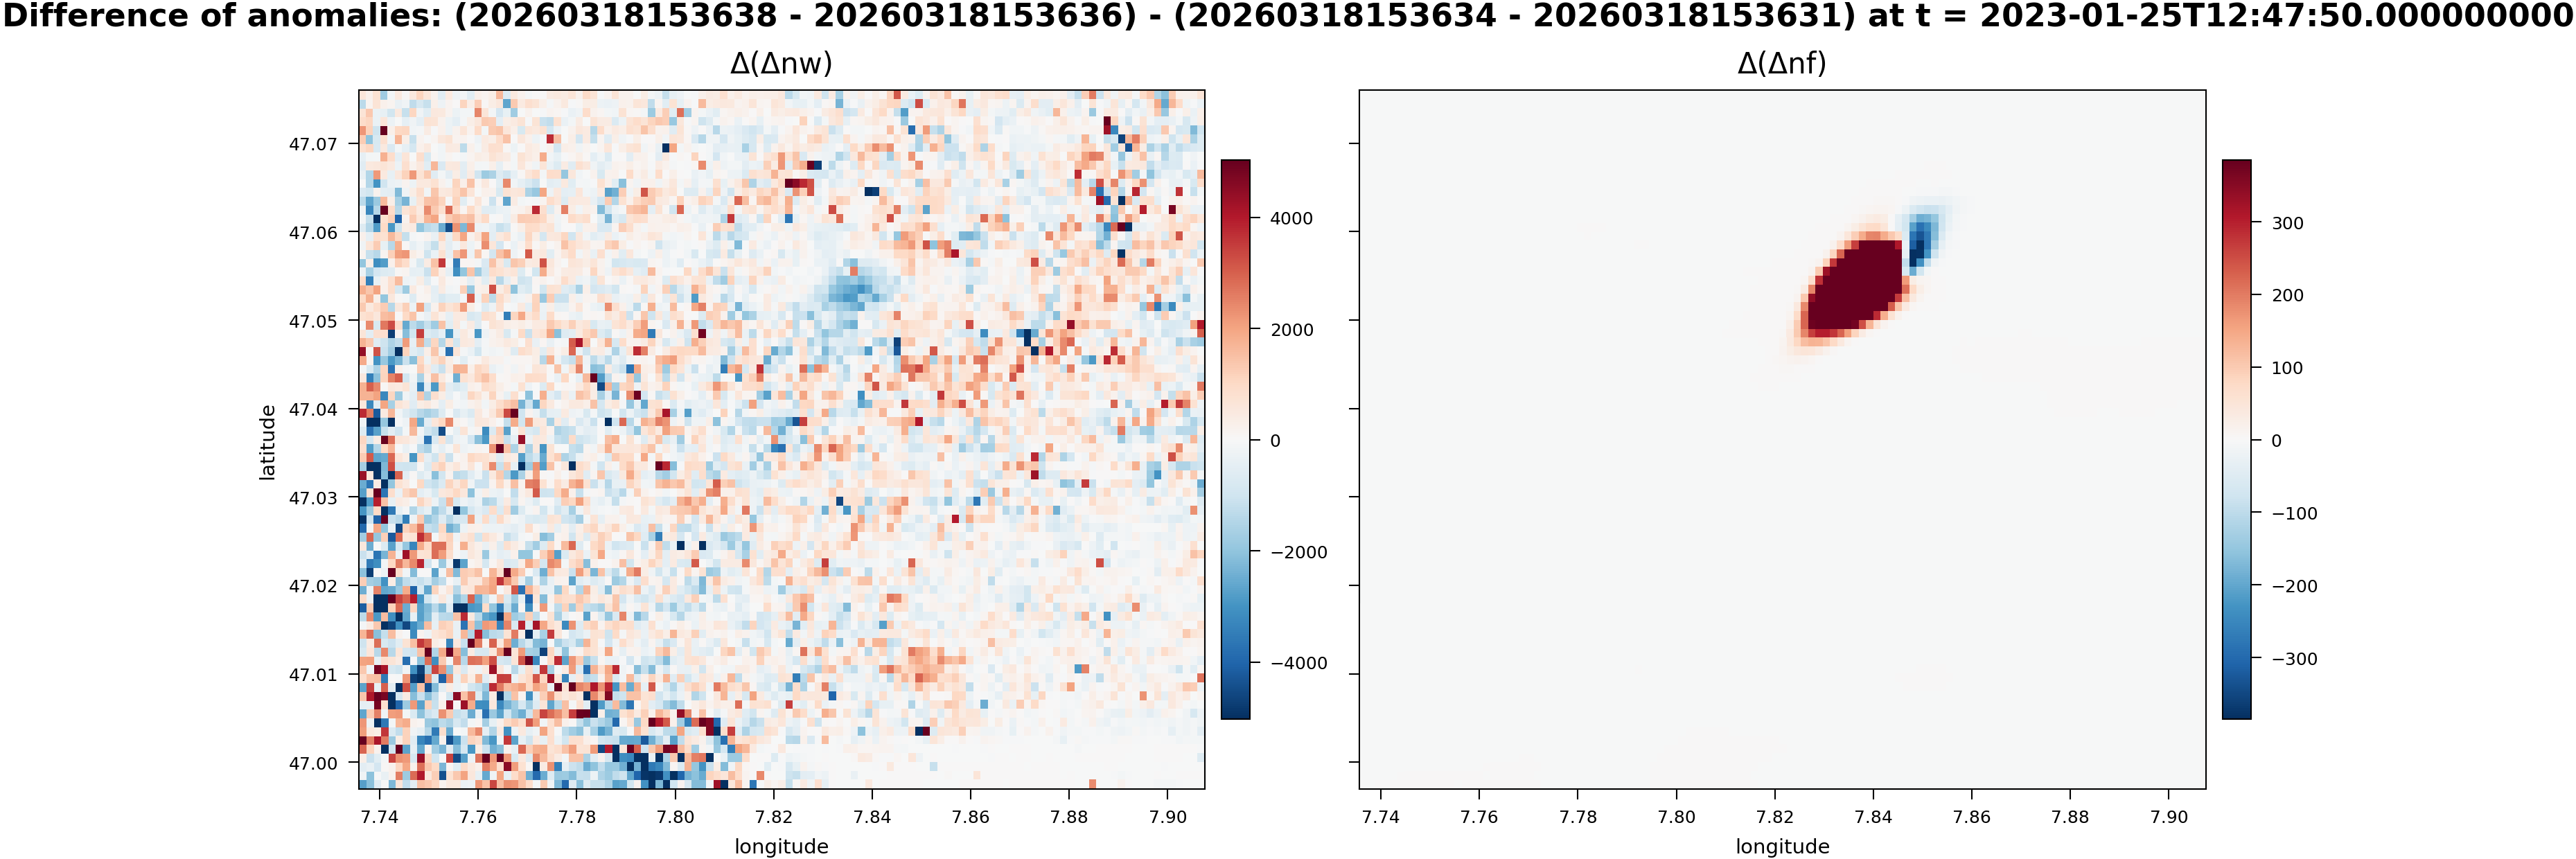

In [22]:

if n_pair < 1:
    raise ValueError("No flare/reference pairs found with matching ishape.")

# 1) Originals: n_flare_runs x 4 -> [flare_nw, flare_nf, ref_nw, ref_nf]
fig_org, axs_org = plt.subplots(n_pair, 4, figsize=(16.0, 3.6 * n_pair), sharex=True, sharey=True, constrained_layout=True)
if n_pair == 1:
    axs_org = np.array([axs_org])

orig_maps = {"nw": [], "nf": []}
for fexp, rexp, _ish in pair_rows:
    for v in ["nw", "nf"]:
        orig_maps[v].append(_col[v].isel(time=itime_cmp).sel(expname=fexp).values)
        orig_maps[v].append(_col[v].isel(time=itime_cmp).sel(expname=rexp).values)
orig_vmin = {v: max( float(np.nanpercentile(np.array(orig_maps[v]),  1.0)), 1e0 ) for v in ["nw", "nf"]}
orig_vmax = {v: max( float(np.nanpercentile(np.array(orig_maps[v]), 99.0)), 1e8) for v in ["nw", "nf"]}

for i, (fexp, rexp, ish) in enumerate(pair_rows):
    panel_data = [
        ("flare nw", _col["nw"].isel(time=itime_cmp).sel(expname=fexp), orig_vmin["nw"], orig_vmax["nw"]),
        ("flare nf", _col["nf"].isel(time=itime_cmp).sel(expname=fexp), orig_vmin["nf"], orig_vmax["nf"]),
        ("ref nw", _col["nw"].isel(time=itime_cmp).sel(expname=rexp), orig_vmin["nw"], orig_vmax["nw"]),
        ("ref nf", _col["nf"].isel(time=itime_cmp).sel(expname=rexp), orig_vmin["nf"], orig_vmax["nf"]),
    ]
    for j, (lbl, da_, vmin_, vmax_) in enumerate(panel_data):
        pm = axs_org[i, j].pcolormesh(
            lon_q,
            lat_q,
            da_.values,
            shading="nearest",
            cmap=new_fjet2,
            norm=LogNorm(vmin=vmin_, vmax=vmax_),
        )
        axs_org[i, j].set_title(f"{lbl} | ishape={ish} | {fexp if 'flare' in lbl else rexp}", fontsize=9)
        fig_org.colorbar(pm, ax=axs_org[i, j], shrink=0.72, pad=0.01)
    axs_org[i, 0].set_ylabel("latitude")
for j in range(4):
    axs_org[-1, j].set_xlabel("longitude")
fig_org.suptitle(f"Original maps (column-integrated) at t = {_tlab}", fontsize=12)

# 2) Anomaly: n_flare_runs x 2 -> [nw_anom, nf_anom] where anomaly = flare - ref.
anom_list = []
for fexp, rexp, ish in pair_rows:
    anom_list.append((
        fexp,
        rexp,
        ish,
        {
            "nw": _col["nw"].isel(time=itime_cmp).sel(expname=fexp) - _col["nw"].isel(time=itime_cmp).sel(expname=rexp),
            "nf": _col["nf"].isel(time=itime_cmp).sel(expname=fexp) - _col["nf"].isel(time=itime_cmp).sel(expname=rexp),
        },
    ))

fig_anom, axs_anom = plt.subplots(n_pair, 2, figsize=(10.0, 3.6 * n_pair), sharex=True, sharey=True, constrained_layout=True)
if n_pair == 1:
    axs_anom = np.array([axs_anom])
anom_vmax = {}
for v in ["nw", "nf"]:
    vals = np.array([a[3][v].values for a in anom_list])
    anom_vmax[v] = max(float(np.nanpercentile(np.abs(vals), 99.0)), 1e-12)

for i, (fexp, rexp, ish, anom) in enumerate(anom_list):
    for j, v in enumerate(["nw", "nf"]):
        vm = anom_vmax[v]
        pm = axs_anom[i, j].pcolormesh(
            lon_q,
            lat_q,
            anom[v].values,
            shading="nearest",
            cmap="RdBu_r",
            vmin=-vm,
            vmax=vm,
        )
        axs_anom[i, j].set_title(f"Δ{v}: ishape={ish} | {fexp} - {rexp}", fontsize=9)
        fig_anom.colorbar(pm, ax=axs_anom[i, j], shrink=0.72, pad=0.01)
    axs_anom[i, 0].set_ylabel("latitude")
for j in range(2):
    axs_anom[-1, j].set_xlabel("longitude")
fig_anom.suptitle(f"Anomaly maps (flare - ref) at t = {_tlab}", fontsize=12)

# 3) Difference of anomalies (nw, nf): using first two anomaly pairs.
if n_pair >= 2:
    diff_anom = {
        "nw": anom_list[1][3]["nw"] - anom_list[0][3]["nw"],
        "nf": anom_list[1][3]["nf"] - anom_list[0][3]["nf"],
    }
    fig_da, axs_da = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True, constrained_layout=True)
    for j, v in enumerate(["nw", "nf"]):
        vm = max(float(np.nanpercentile(np.abs(diff_anom[v].values), 99.0)), 1e-12)
        pm = axs_da[j].pcolormesh(
            lon_q,
            lat_q,
            diff_anom[v].values,
            shading="nearest",
            cmap="RdBu_r",
            vmin=-vm,
            vmax=vm,
        )
        axs_da[j].set_title(f"Δ(Δ{v})", fontsize=10)
        axs_da[j].set_xlabel("longitude")
        fig_da.colorbar(pm, ax=axs_da[j], shrink=0.80, pad=0.02)
    axs_da[0].set_ylabel("latitude")
    p0 = f"({anom_list[0][0]} - {anom_list[0][1]})"
    p1 = f"({anom_list[1][0]} - {anom_list[1][1]})"
    fig_da.suptitle(f"Difference of anomalies: {p1} - {p0} at t = {_tlab}", fontsize=11)
else:
    print("Need >=2 pairs for difference-of-anomalies figure.")

In [23]:

# moved into previous cell (pair/original/anomaly/diff-anomaly workflow)
pass


In [24]:

# moved into previous cell (pair/original/anomaly/diff-anomaly workflow)
print_ensemble_config_diff(meta, flare_candidates + ref_candidates, subtrees=("INPUT_ORG", "domain"))


Ensemble config differences (COSMO-SPECS / INPUT_ORG)
experiments (7): 20260318153634, 20260318153638, 20260324165035, 20260324165038, 20260324165040, 20260318153631, 20260318153636

INPUT_ORG.flare_sbm.flare_dn
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 400.0
  20260324165038: 400.0
  20260324165040: 400.0
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_dp
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1e-07
  20260324165038: 1e-07
  20260324165040: 1e-07
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_emission
  20260318153634: 1000000.0
  20260318153638: 1000000.0
  20260324165035: 1000000.0
  20260324165038: 3000000.0
  20260324165040: 10000000.0
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.flare_sig
  20260318153634: 0.0
  20260318153638: 0.0
  20260324165035: 1.75
  20260324165038: 1.75
  20260324165040: 1.75
  20260318153631: 0.0
  20260318153636: 0.0

INPUT_ORG.flare_sbm.lflare_c

In [25]:
# Tracking overlays (optional): time slice from publication cloud_field_overview preset
if plot_start_s and plot_end_s:
    plot_time_frame = [np.datetime64(plot_start_s), np.datetime64(plot_end_s)]
else:
    plot_time_frame = [seed_start, seed_start + np.timedelta64(2, "h")]

# tracks_csv = tools.load_tracking_csv(str(model_data_path / "lv1_tracking" /f"{flare_exp_name}_nf_tobac_track.csv"))

# def _tracks_by_cell(df, t0, step=6):
#     out = []
#     for _, g in df.groupby("cell"):
#         sub = g[pd.to_datetime(g["time"]) >= t0][::step]
#         if len(sub):
#             out.append(sub)
#     return out

# cell_tracks = _tracks_by_cell(tracks_csv, plot_time_frame[0])

## Plotting helpers (plan view)

In [26]:
def add_map_annotations(ax, cfg):
    ax.scatter(cfg["origin_lon"], cfg["origin_lat"], s=70, marker="x", color="red", zorder=2)
    ax.scatter(
        cfg["flare_lon"],
        cfg["flare_lat"],
        s=50,
        marker="o",
        facecolor="none",
        edgecolor="white",
        lw=2.5,
        zorder=2,
    )
    ax.scatter(
        cfg["flare_lon"],
        cfg["flare_lat"],
        s=50,
        marker="o",
        facecolor="none",
        edgecolor="red",
        lw=1.0,
        zorder=2,
    )
    add_ruler(ax, 47.05, 7.804, cfg["flare_lat"], cfg["flare_lon"])
    seeding = {
        "royalblue": ([7.90476, 7.90568], [47.07602, 47.07248]),
        "orange": ([7.89828, 7.89919], [47.07526, 47.07172]),
        "green": ([7.91125, 7.91216], [47.07676, 47.07322]),
    }
    for _c, (lon, lat) in seeding.items():
        dx, dy = np.diff(lon)[0], np.diff(lat)[0]
        ext_lon, ext_lat = [lon[0] - dx, lon[1] + dx], [lat[0] - dy, lat[1] + dy]
        ax.plot(lon, lat, color="black", lw=0.9)
        ax.plot(ext_lon, ext_lat, color="black", alpha=0.4, lw=0.6)
        ax.scatter(lon, lat, color="black", marker=".", s=15)


def setup_plot_lat_lon(cfg):
    w_in = cfg["pixel_size_latlon"][0] / cfg["dpi"]
    h_in = cfg["pixel_size_latlon"][1] / cfg["dpi"]
    fig, ax = plt.subplots(figsize=(w_in, h_in), constrained_layout=True)
    ax.set_xlim(cfg["plot_xlim"])
    ax.set_ylim(cfg["plot_ylim"])
    set_name_tick_params(ax)
    ax.tick_params(axis="both", which="major", labelsize=cfg["tick_size"])
    return fig, ax


def add_plan_colorbars(fig, ax, pmesh, cfg):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cb_qi = fig.colorbar(pmesh[0], ax=ax, extend="both", shrink=0.7, aspect=15, pad=0.01)
    cb_qi.ax.text(
        0.52,
        4e-1 * cfg["v_lims_qi"][0],
        r"$\sum\,$ICNC"+"\n"+r"(m$^{-2}$)",
        ha="center",
        va="top",
        fontsize=cfg["axis_size"] - 1,
    )
    cb_surf = fig.colorbar( pmesh[1], ax=ax, extend="both", shrink=0.5, aspect=20, pad=0.1, orientation="horizontal")
    cb_surf.set_label("height a.m.s.l. / (m)", fontsize=cfg["tick_size"], labelpad=2)
    cb_surf.ax.tick_params(labelsize=cfg["tick_size"] - 1)
    return [cb_qi, cb_surf]


def update_plan_frame(iframe, fig, ax, pmesh, cell_plots, cfg, time, z_val, cell_tracks_1, cell_tracks_2):
    for txt in fig.texts:
        if "UTC" in txt.get_text():
            txt.set_visible(False)
    # z_val may be xarray DataArray (no .ravel); matplotlib needs a 1D numpy array.
    pmesh[0].set_array(np.asarray(z_val[iframe, :, :]).ravel())
    ts = np.datetime_as_string(time[iframe], unit="s").replace("T", "  ")
    fig.text(
        0.96,
        0.99,
        f"{ts[-8:]} UTC",
        ha="right",
        va="bottom",
        fontweight="semibold",
        fontsize=cfg["timer_size"],
    )
    if cell_tracks_1 or cell_tracks_2:
        for p in cell_plots:
            p.remove()
        cell_plots.clear()
    cur = time[iframe]
    if cell_tracks_2 is not None:
        for ct in cell_tracks_2:
            tr = ct[pd.to_datetime(ct["time"]) <= cur]
            if not tr.empty:
                cell_plots.append(
                    ax.scatter(tr.longitude.values, tr.latitude.values, c="#F18F01", s=30, alpha=0.95, marker="+", zorder=90)
                )
    if cell_tracks_1 is not None:
        for ct in cell_tracks_1:
            tr = ct[pd.to_datetime(ct["time"]) <= cur]
            if not tr.empty:
                cell_plots.append(
                    ax.scatter(tr.longitude.values, tr.latitude.values, c="#2E86AB", s=30, alpha=0.95, marker="x", zorder=90)
                )
    out = GFX_PNG / f"lat_lon_frame_{iframe:03d}_{cfg['resolution']}_area.png"
    fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")


## Plan-view animation

In [ ]:
apply_publication_style()

png_path = str(GFX_PNG)
os.makedirs(png_path, exist_ok=True)

# Build plan-view ICNC fields for all flare runs (columns).
plan_by_exp = {}
for exp in flare_candidates:
    mod_e = ds_3d.sel(expname=exp)[["nf", "dz"]].sel(
        latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
        longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
    )
    mod_e = mod_e.isel(diameter=slice(30, None)).sum("diameter")
    mod_e = (mod_e[["nf"]] * mod_e["dz"]).sum("altitude")
    with ProgressBar():
        mod_e = xr.where(mod_e < np.finfo(np.float32).eps, np.nan, mod_e).persist()
    plan_by_exp[exp] = mod_e["nf"]

# Harmonize plan-view time to the finest cadence (10 s) on reduced 2D fields only.
plan_blocks = [plan_by_exp[exp].to_dataset(name="nf") for exp in flare_candidates]
plan_blocks = harmonize_experiment_time_to_finest(plan_blocks, exp_names=flare_candidates)
for exp, ds_h in zip(flare_candidates, plan_blocks):
    plan_by_exp[exp] = ds_h["nf"]

n_flare = len(flare_candidates)
time_vals = plan_by_exp[flare_candidates[0]].time.values

fig_w = (cfg["pixel_size_latlon"][0] / cfg["dpi"]) * max(1, n_flare)
fig_h = cfg["pixel_size_latlon"][1] / cfg["dpi"]
fig, axs = plt.subplots(1, n_flare, figsize=(fig_w, fig_h), sharex=True, sharey=True, constrained_layout=True)
if n_flare == 1:
    axs = np.array([axs])

pm_qi_all = []
for ax, exp in zip(axs, flare_candidates):
    set_name_tick_params(ax)
    ax.tick_params(axis="both", which="major", labelsize=cfg["tick_size"])
    add_map_annotations(ax, cfg)
    ax.pcolormesh(lon2d, lat2d, height, cmap="terrain", vmin=300, alpha=0.55, zorder=1)
    pm_qi = ax.pcolormesh(
        plan_by_exp[exp].longitude2D,
        plan_by_exp[exp].latitude2D,
        np.asarray(plan_by_exp[exp].isel(time=0).values),
        cmap=new_fjet2,
        norm=LogNorm(*cfg["v_lims_qi"]),
        zorder=50,
    )
    pm_qi_all.append(pm_qi)
    ax.set_title(f"flare {exp}", fontsize=cfg["axis_size"], weight="semibold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)

fig.text(0.5, 0.03, "longitude / (°)", ha="center", va="center", fontsize=cfg["axis_size"])
fig.text(0.01, 0.5, "latitude / (°)", ha="center", va="center", fontsize=cfg["axis_size"], rotation="vertical")
cb_qi = fig.colorbar(pm_qi_all[0], ax=axs.ravel().tolist(), extend="both", shrink=0.85, aspect=25, pad=0.02)
cb_qi.set_label(r"$\sum$ ICNC (m$^{-2}$)", fontsize=cfg["axis_size"] - 1)
cb_qi.ax.tick_params(labelsize=cfg["tick_size"])
fig.suptitle("Top-view flare ICNC evolution", fontsize=cfg["timer_size"] - 1, weight="semibold", y=0.995)

for pattern in ("lat_lon_frame_*.png",):
    for f in glob.glob(os.path.join(png_path, pattern)):
        os.remove(f)
print("Cleaned:", png_path)

if cfg["plot_all_frames"]:
    for iframe in range(len(time_vals)):
        for txt in fig.texts:
            if "UTC" in txt.get_text():
                txt.set_visible(False)
        for pm_qi, exp in zip(pm_qi_all, flare_candidates):
            pm_qi.set_array(np.asarray(plan_by_exp[exp].isel(time=iframe).values).ravel())
        ts = np.datetime_as_string(time_vals[iframe], unit="s").replace("T", "  ")
        fig.text(0.98, 0.96, f"{ts[-8:]} UTC", ha="right", va="top", fontweight="semibold", fontsize=cfg["timer_size"])
        out = GFX_PNG / f"lat_lon_frame_{iframe:03d}_{cfg['resolution']}_area.png"
        fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")
    print("All multi-column plan-view frames saved")

input_pattern = os.path.join(png_path, f"lat_lon_frame_%03d_{cfg['resolution']}_area.png")
out_mp4 = GFX_MP4 / f"lat_lon_multi_flare_{cfg['resolution']}_{cs_run.replace('__', '_')}.mp4"
out_gif = out_mp4.with_suffix(".gif")
tools.convert_to_video(str(input_pattern), str(out_mp4), resolution="1920:1080", loop_count=2, framerate=15)
tools.convert_to_gif(str(input_pattern), str(out_gif), scale_factor=0.5, fps=20)
print(out_mp4.resolve().as_uri())
print(out_gif.resolve().as_uri())


[########################################] | 100% Completed | 42.71 ss
[########################################] | 100% Completed | 43.22 ss
[########################################] | 100% Completed | 43.01 s
[########################################] | 100% Completed | 44.07 s
[########################################] | 100% Completed | 41.89 s
Cleaned: /home/b/b382237/code/polarcap/python/polarcap_analysis/output/gfx/png/aerials/cs-eriswil__20260318_153631


## Latitude–height section + domain ice mass

Uses the same `cfg`, `ds_3d`, and `GFX_*` roots. Time-series colours use `proc_color` (Okabe–Ito) from `style_profiles`.

In [ ]:

def compute_integrated_water_contents(ds_3d_local):
    dss = ds_3d_local[["qc", "qi", "qs", "qv", "dz"]]
    wc = {
        "IWC": (dss["qi"] * dss["dz"] * cfg["delta_x"] * cfg["delta_y"]).sum(
            ["altitude", "longitude", "latitude"]
        ),
        "LWC": (dss["qc"] * dss["dz"] * cfg["delta_x"] * cfg["delta_y"]).sum(
            ["altitude", "longitude", "latitude"]
        ),
        "SWC": (dss["qs"] * dss["dz"] * cfg["delta_x"] * cfg["delta_y"]).sum(
            ["altitude", "longitude", "latitude"]
        ),
        "VC": (dss["qv"] * dss["dz"] * cfg["delta_x"] * cfg["delta_y"]).sum(
            ["altitude", "longitude", "latitude"]
        ),
    }
    wc["TWC"] = wc["IWC"] + wc["LWC"] + wc["VC"]
    wc["TIWC"] = wc["IWC"] + wc["SWC"]
    return xr.Dataset(wc)


water_contents = compute_integrated_water_contents(ds_3d.sel(expname=flare_exp_name))
with ProgressBar():
    water_contents = water_contents.persist()

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import AutoMinorLocator


def setup_plot_with_timeseries(cfg):
    total_width = cfg["pixel_size_latheight"][0] / cfg["dpi"]
    main_height = cfg["pixel_size_latheight"][1] / cfg["dpi"]
    ts_height = main_height * 0.33
    fig = plt.figure(figsize=(total_width, main_height + ts_height), constrained_layout=True)
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 3], hspace=0.05)
    ax_ts = fig.add_subplot(gs[0])
    ax_main = fig.add_subplot(gs[1])
    ax_main.set_ylim((600, 1500))
    set_name_tick_params(ax_main)
    set_name_tick_params(ax_ts)
    # ax_hist = inset_axes(
    #     ax_main,
    #     width="30%",
    #     height="40%",
    #     loc="upper right",
    #     bbox_to_anchor=(-0.05, -0.05, 1.0, 1.0),
    #     bbox_transform=ax_main.transAxes,
    # )
    # ax_hist.tick_params(axis="both", which="major", labelsize=cfg["tick_size"] - 2)
    # ax_hist.patch.set_alpha(0.8)
    return fig, ax_main, ax_ts


def plot_timeseries_dual_axis(ax_ts, water_contents, current_time, cfg):
    ax_ts.clear()
    time = water_contents["IWC"].time.values
    colors_left = {"IWC": proc_color("CONDENSATION"), "SWC": proc_color("DROP_COLLISION"), "TIWC": "#000000"}
    lines, labels = [], ["IWC", "SWC", "TIWC"]
    for key in labels:
        line, = ax_ts.plot(
            time,
            water_contents[key].values * 1e-3,
            color=colors_left[key],
            lw=2.0 if key == "TIWC" else 1.5,
            alpha=1.0 if key == "TIWC" else 0.9,
            label=key,
        )
        lines.append(line)
    ax_ts.axvline(current_time, color="black", linestyle="--", lw=1, alpha=0.75, zorder=10)
    ax_ts.set_xlim(time[0], time[-1])
    ax_ts.set_xlabel("time / (UTC)", fontsize=cfg["axis_size"], color="black")
    ax_ts.set_ylabel("ice mass / (kg)", fontsize=cfg["axis_size"], color="black")
    ax_ts.set_axisbelow(True)
    ax_ts.ticklabel_format(axis="y", style="scientific", scilimits=(-3, +3))
    ax_ts.xaxis.set_major_formatter(md.DateFormatter("%H:%M"))
    ax_ts.xaxis.set_minor_locator(AutoMinorLocator())
    ax_ts.yaxis.set_minor_locator(AutoMinorLocator())
    ax_ts.tick_params(axis="both", which="major", direction="inout", top=True, right=True, labelsize=cfg["tick_size"])
    ax_ts.tick_params(axis="both", which="minor", direction="inout", top=True, right=True, labelsize=cfg["tick_size"])
    ax_ts.grid(which="both", linestyle="--", alpha=1, lw=0.15, color="black")
    # ax_ts.grid(which="minor", linestyle="--", alpha=0.05, lw=0.25, color="black")
    ax_ts.legend(lines, labels, loc="upper left", ncol=4, fontsize=cfg["tick_size"], framealpha=0.9, edgecolor="none")


def _latheight_surf_lon_index(iframe, n_time, n_lon):
    if n_lon <= 1:
        return 0
    if n_time <= 1:
        return 0
    return int(round(iframe * (n_lon - 1) / (n_time - 1)))


def update_frame_enhanced(
    iframe, fig, ax_main, ax_ts, pmesh, cfg, time_values, IWC_lat, water_contents, lat_height_surf=None
):
    for txt in fig.texts:
        if "UTC" in txt.get_text():
            txt.set_visible(False)
    pmesh[0].set_array(IWC_lat[iframe, :, :].ravel())
    if lat_height_surf is not None and lat_height_surf.get("mode") == "individual":
        line = lat_height_surf.get("current_line")
        sh = lat_height_surf.get("surf_height")
        if line is not None and sh is not None:
            j = _latheight_surf_lon_index(iframe, IWC_lat.shape[0], sh.shape[1])
            line.set_ydata(sh[:, j])
    cur = time_values[iframe]
    plot_timeseries_dual_axis(ax_ts, water_contents, cur, cfg)
    ts = np.datetime_as_string(cur, unit="s").replace("T", "  ")
    fig.text(
        0.96,
        0.99,
        f"{ts[-8:]} UTC",
        ha="right",
        va="top",
        fontweight="semibold",
        fontsize=cfg["timer_size"],
    )
    out = GFX_PNG / f"lat_height_frame_{iframe:03d}_{cfg['resolution']}.png"
    fig.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")



data_extpar2 = xr.open_mfdataset(str(extpar_file), chunks="auto")
lat1d = data_extpar2["lat"].mean("rlon").values[7:-7]
surf_height = data_extpar2["HSURF"].values[7:-7, 7:-7]
surf_height_mean = data_extpar2["HSURF"].mean("rlon").values[7:-7]

# Lat-height fields for all flare runs (columns).
lat_by_exp = {}
lat_by_exp2 = {}
for exp in flare_candidates:
    mod_lat = ds_3d.sel(expname=exp)[["nf", "nw"]].sel(
        latitude=slice(None, cfg["flare_lat"] + 2.0 * cfg["resolution_deg"]),
        longitude=slice(None, cfg["flare_lon"] + 2.0 * cfg["resolution_deg"]),
    )
    mod_lat = xr.where(mod_lat < 1e-2, np.nan, mod_lat)
    mod_lat = (mod_lat * cfg["delta_x"]).sum("longitude")
    mod_lat = mod_lat.isel(diameter=slice(30, None)).sum("diameter")
    with ProgressBar():
        mod_lat = mod_lat.persist()
    lat_by_exp[exp] = mod_lat["nf"]
    lat_by_exp2[exp] = mod_lat["nw"]

# Harmonize lat-height time to finest cadence (10 s) on reduced fields.
lat_nf_blocks = [lat_by_exp[exp].to_dataset(name="nf") for exp in flare_candidates]
lat_nf_blocks = harmonize_experiment_time_to_finest(lat_nf_blocks, exp_names=flare_candidates)
for exp, ds_h in zip(flare_candidates, lat_nf_blocks):
    lat_by_exp[exp] = ds_h["nf"]

lat_nw_blocks = [lat_by_exp2[exp].to_dataset(name="nw") for exp in flare_candidates]
lat_nw_blocks = harmonize_experiment_time_to_finest(lat_nw_blocks, exp_names=flare_candidates)
for exp, ds_h in zip(flare_candidates, lat_nw_blocks):
    lat_by_exp2[exp] = ds_h["nw"]

height1d = lat_by_exp[flare_candidates[0]].altitude.values
time1d = lat_by_exp[flare_candidates[0]].time.values
print("lat-height arrays:", {k: tuple(v.shape) for k, v in lat_by_exp.items()})


In [ ]:
idx_time = min(130, len(time1d) - 1)
n_flare = len(flare_candidates)
fig_w = (cfg["pixel_size_latheight"][0] / cfg["dpi"])
fig_h = cfg["pixel_size_latheight"][1] / cfg["dpi"] * max(1, n_flare)
fig_lh, axs_lh = plt.subplots(n_flare, 1, figsize=(fig_w, fig_h), sharex=True, sharey=True, constrained_layout=True)
if n_flare == 1:
    axs_lh = np.array([axs_lh])

pm_qi_lh_all = []
for ax, exp in zip(axs_lh, flare_candidates):
    ax.plot(lat1d, surf_height_mean, color="black", alpha=0.9, lw=2, zorder=3)
    if cfg.get("latheight_surf_mode", "all_mean") == "all_mean":
        ax.plot(lat1d, surf_height, color="black", alpha=0.035 if "100m" in cfg["resolution"] else 0.075)
    pm_qi = ax.pcolormesh(
        lat1d[: lat_by_exp[exp].shape[-1]],
        height1d,
        lat_by_exp[exp].isel(time=idx_time).values,
        cmap=new_fjet2,
        norm=LogNorm(*cfg["v_lims_qi"]),
        shading="nearest",
        zorder=2,
    )
    pm_qi_lh_all.append(pm_qi)
    ax.set_title(f"flare {exp}", fontsize=10)
    ax.tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig_lh.text(0.5, 0.02, "latitude / (°)", ha="center", va="center", fontsize=cfg["axis_size"])
fig_lh.text(0.01, 0.5, "height a.m.s.l. / (m)", ha="center", va="center", fontsize=cfg["axis_size"], rotation="vertical")
cb_qi_lh = fig_lh.colorbar(pm_qi_lh_all[0], ax=axs_lh.ravel().tolist(), pad=0.02, extend="both", shrink=0.85, aspect=25)
cb_qi_lh.set_label(r"$\sum$ ICNC lat-height (m$^{-2}$)")
cb_qi_lh.ax.tick_params(labelsize=cfg["tick_size"])



In [ ]:
for f in glob.glob(str(GFX_PNG / "lat_height_frame_*.png")):
    os.remove(f)

if cfg["plot_all_frames"]:
    for iframe in range(len(time1d)):
        for txt in fig_lh.texts:
            if "UTC" in txt.get_text():
                txt.set_visible(False)
        for pm_qi, pm_nw, exp in zip(pm_qi_lh_all, pm_nw_lh_all, flare_candidates):
            pm_qi.set_array(np.asarray(lat_by_exp[exp].isel(time=iframe).values).ravel())
            pm_nw.set_array(np.asarray(lat_by_exp2[exp].isel(time=iframe).values).ravel())
        cur = time1d[iframe]
        ts = np.datetime_as_string(cur, unit="s").replace("T", "  ")
        fig_lh.text(0.98, 0.98, f"{ts[-8:]} UTC", ha="right", va="top", fontweight="semibold", fontsize=cfg["timer_size"])
        out = GFX_PNG / f"lat_height_frame_{iframe:03d}_{cfg['resolution']}.png"
        fig_lh.savefig(out, dpi=cfg["dpi"], bbox_inches="tight")

    pat = str(GFX_PNG / f"lat_height_frame_%03d_{cfg['resolution']}.png")
    mp4_lh = GFX_MP4 / f"lat_height_multi_flare_{cfg['resolution']}_{cs_run.replace('__', '_')}.mp4"
    gif_lh = mp4_lh.with_suffix(".gif")
    tools.convert_to_video(pat, str(mp4_lh), resolution="1920:1080", loop_count=2, framerate=20)
    tools.convert_to_gif(pat, str(gif_lh), scale_factor=0.5, fps=10)
    print(mp4_lh, gif_lh)
else:
    for pm_qi, exp in zip(pm_qi_lh_all, flare_candidates):
        pm_qi.set_array(np.asarray(lat_by_exp[exp].isel(time=0).values).ravel())


In [ ]:
#here